In [13]:
# Dataframe Manipulation
import pandas as pd
#For removing any special characters
import re
#For removing stopwords
import nltk
nltk.download('stopwords',quiet = True)
#Stemming the text
from nltk.stem import PorterStemmer
#Importing NumPy
import numpy as np
# Ignore warnings
import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

In [8]:
#Downloading nltk StopWords and Wordnet 
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\avira\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\avira\AppData\Roaming\nltk_data...


True

In [10]:
Dataset1 = pd.read_csv("data.csv")

In [11]:
Dataset1

,URLs,Headline,Body,Label
0,http://www.bbc.com/news/world-us-canada-414191...,Four ways Bob Corker skewered Donald Trump,Image copyright Getty Images\nOn Sunday mornin...,1
1,https://www.reuters.com/article/us-filmfestiva...,Linklater's war veteran comedy speaks to moder...,"LONDON (Reuters) - “Last Flag Flying”, a comed...",1
2,https://www.nytimes.com/2017/10/09/us/politics...,Trump’s Fight With Corker Jeopardizes His Legi...,The feud broke into public view last week when...,1
3,https://www.reuters.com/article/us-mexico-oil-...,Egypt's Cheiron wins tie-up with Pemex for Mex...,MEXICO CITY (Reuters) - Egypt’s Cheiron Holdin...,1
4,http://www.cnn.com/videos/cnnmoney/2017/10/08/...,Jason Aldean opens 'SNL' with Vegas tribute,"Country singer Jason Aldean, who was performin...",1
...,...,...,...,...
4004,http://beforeitsnews.com/sports/2017/09/trends...,Trends to Watch,Trends to Watch\n% of readers think this story...,0
4005,http://beforeitsnews.com/u-s-politics/2017/10/...,Trump Jr. Is Soon To Give A 30-Minute Speech F...,Trump Jr. Is Soon To Give A 30-Minute Speech F...,0
4006,https://www.activistpost.com/2017/09/ron-paul-...,"Ron Paul on Trump, Anarchism & the AltRight",NaN,0
4007,https://www.reuters.com/article/us-china-pharm...,China to accept overseas trial data in bid to ...,SHANGHAI (Reuters) - China said it plans to ac...,1


In [12]:
Dataset1.nunique()

URLs        3254
Headline    2831
Body        2863
Label          2
dtype: int64

In [14]:
Dataset1.count()

URLs        4009
Headline    4009
Body        3988
Label       4009
dtype: int64

In [24]:
Dataset1.isna().sum()

URLs           0
Headline       0
Body          21
Label          0
Clean_data    21
dtype: int64

In [27]:
Dataset1 = Dataset1.dropna(subset=['Body','Clean_data'])

In [28]:
Dataset1.isna().sum()

URLs          0
Headline      0
Body          0
Label         0
Clean_data    0
dtype: int64

In [42]:
#Copying the original data into another column that we will clean. We will do this so that we can see the changes that happen in our data.
Dataset1.loc[:,'Clean_data'] = Dataset1['Headline'] + Dataset1['Body']
Dataset1.head()

,URLs,Headline,Body,Label,Clean_data
0,http://www.bbc.com/news/world-us-canada-414191...,Four ways Bob Corker skewered Donald Trump,Image copyright Getty Images\nOn Sunday mornin...,1,Four ways Bob Corker skewered Donald TrumpImag...
1,https://www.reuters.com/article/us-filmfestiva...,Linklater's war veteran comedy speaks to moder...,"LONDON (Reuters) - “Last Flag Flying”, a comed...",1,Linklater's war veteran comedy speaks to moder...
2,https://www.nytimes.com/2017/10/09/us/politics...,Trump’s Fight With Corker Jeopardizes His Legi...,The feud broke into public view last week when...,1,Trump’s Fight With Corker Jeopardizes His Legi...
3,https://www.reuters.com/article/us-mexico-oil-...,Egypt's Cheiron wins tie-up with Pemex for Mex...,MEXICO CITY (Reuters) - Egypt’s Cheiron Holdin...,1,Egypt's Cheiron wins tie-up with Pemex for Mex...
4,http://www.cnn.com/videos/cnnmoney/2017/10/08/...,Jason Aldean opens 'SNL' with Vegas tribute,"Country singer Jason Aldean, who was performin...",1,Jason Aldean opens 'SNL' with Vegas tributeCou...


In [33]:
#Convert the text into lowercase
Dataset1.loc[:,'Clean_data'] = Dataset1['Clean_data'].str.lower()
Dataset1.head()

,URLs,Headline,Body,Label,Clean_data
0,http://www.bbc.com/news/world-us-canada-414191...,Four ways Bob Corker skewered Donald Trump,Image copyright Getty Images\nOn Sunday mornin...,1,four ways bob corker skewered donald trumpimag...
1,https://www.reuters.com/article/us-filmfestiva...,Linklater's war veteran comedy speaks to moder...,"LONDON (Reuters) - “Last Flag Flying”, a comed...",1,linklater's war veteran comedy speaks to moder...
2,https://www.nytimes.com/2017/10/09/us/politics...,Trump’s Fight With Corker Jeopardizes His Legi...,The feud broke into public view last week when...,1,trump’s fight with corker jeopardizes his legi...
3,https://www.reuters.com/article/us-mexico-oil-...,Egypt's Cheiron wins tie-up with Pemex for Mex...,MEXICO CITY (Reuters) - Egypt’s Cheiron Holdin...,1,egypt's cheiron wins tie-up with pemex for mex...
4,http://www.cnn.com/videos/cnnmoney/2017/10/08/...,Jason Aldean opens 'SNL' with Vegas tribute,"Country singer Jason Aldean, who was performin...",1,jason aldean opens 'snl' with vegas tributecou...


In [37]:
#Removing any kind of special characters that might be present in out text by defining a function
def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)
    
#Applying it to the whole dataset
Dataset1.loc[:,'Clean_data'] = Dataset1['Clean_data'].apply(remove_special_chars)

#Checking if it worked
Dataset1.head()

,URLs,Headline,Body,Label,Clean_data
0,http://www.bbc.com/news/world-us-canada-414191...,Four ways Bob Corker skewered Donald Trump,Image copyright Getty Images\nOn Sunday mornin...,1,four ways bob corker skewered donald trumpimag...
1,https://www.reuters.com/article/us-filmfestiva...,Linklater's war veteran comedy speaks to moder...,"LONDON (Reuters) - “Last Flag Flying”, a comed...",1,linklaters war veteran comedy speaks to modern...
2,https://www.nytimes.com/2017/10/09/us/politics...,Trump’s Fight With Corker Jeopardizes His Legi...,The feud broke into public view last week when...,1,trumps fight with corker jeopardizes his legis...
3,https://www.reuters.com/article/us-mexico-oil-...,Egypt's Cheiron wins tie-up with Pemex for Mex...,MEXICO CITY (Reuters) - Egypt’s Cheiron Holdin...,1,egypts cheiron wins tieup with pemex for mexic...
4,http://www.cnn.com/videos/cnnmoney/2017/10/08/...,Jason Aldean opens 'SNL' with Vegas tribute,"Country singer Jason Aldean, who was performin...",1,jason aldean opens snl with vegas tributecount...


In [40]:
#Removing stopwords from the text

from nltk.corpus import stopwords

#Filtering out the stopwords for english only
stop_words = set(stopwords.words('english'))

#Defining a function to remove all the stopwords
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

Dataset1.loc[:,'Clean_data'] = Dataset1['Clean_data'].apply(remove_stopwords)
Dataset1.head()

,URLs,Headline,Body,Label,Clean_data
0,http://www.bbc.com/news/world-us-canada-414191...,Four ways Bob Corker skewered Donald Trump,Image copyright Getty Images\nOn Sunday mornin...,1,four ways bob corker skewered donald trumpimag...
1,https://www.reuters.com/article/us-filmfestiva...,Linklater's war veteran comedy speaks to moder...,"LONDON (Reuters) - “Last Flag Flying”, a comed...",1,linklaters war veteran comedy speaks modern am...
2,https://www.nytimes.com/2017/10/09/us/politics...,Trump’s Fight With Corker Jeopardizes His Legi...,The feud broke into public view last week when...,1,trumps fight corker jeopardizes legislative ag...
3,https://www.reuters.com/article/us-mexico-oil-...,Egypt's Cheiron wins tie-up with Pemex for Mex...,MEXICO CITY (Reuters) - Egypt’s Cheiron Holdin...,1,egypts cheiron wins tieup pemex mexican onshor...
4,http://www.cnn.com/videos/cnnmoney/2017/10/08/...,Jason Aldean opens 'SNL' with Vegas tribute,"Country singer Jason Aldean, who was performin...",1,jason aldean opens snl vegas tributecountry si...


In [41]:
# Stemming the data
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
def stem_words(text):
    words = text.split()
    words = [stemmer.stem(word) for word in words]
    return " ".join(words)

Dataset1.loc[:,'Clean_data'] = Dataset1['Clean_data'].apply(stem_words)
display(Dataset1.head())

,URLs,Headline,Body,Label,Clean_data
0,http://www.bbc.com/news/world-us-canada-414191...,Four ways Bob Corker skewered Donald Trump,Image copyright Getty Images\nOn Sunday mornin...,1,four way bob corker skewer donald trumpimag co...
1,https://www.reuters.com/article/us-filmfestiva...,Linklater's war veteran comedy speaks to moder...,"LONDON (Reuters) - “Last Flag Flying”, a comed...",1,linklat war veteran comedi speak modern americ...
2,https://www.nytimes.com/2017/10/09/us/politics...,Trump’s Fight With Corker Jeopardizes His Legi...,The feud broke into public view last week when...,1,trump fight corker jeopard legisl agendath feu...
3,https://www.reuters.com/article/us-mexico-oil-...,Egypt's Cheiron wins tie-up with Pemex for Mex...,MEXICO CITY (Reuters) - Egypt’s Cheiron Holdin...,1,egypt cheiron win tieup pemex mexican onshor o...
4,http://www.cnn.com/videos/cnnmoney/2017/10/08/...,Jason Aldean opens 'SNL' with Vegas tribute,"Country singer Jason Aldean, who was performin...",1,jason aldean open snl vega tributecountri sing...


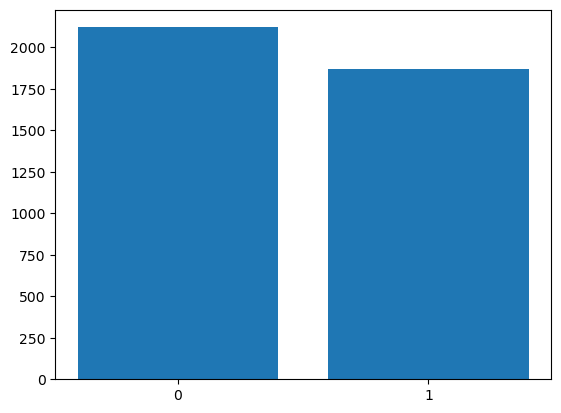

In [51]:
import matplotlib.pyplot as plt
values = Dataset1['Label'].value_counts()
x = values.index
y = values.values
plt.bar(x,y)
plt.xticks([0,1])
plt.show()